In [19]:
import numpy as np
from scipy.io import loadmat

In [20]:
def load_signal(path):
    mat=loadmat(path)
    key=[k for k in mat.keys() if 'DE_time' in k][0]
    return mat[key].flatten()

In [21]:
files = {
    '../data/raw/Time_Normal_1_098.mat': 'Normal',
    '../data/raw/IR007_1_110.mat':  'IR007',
    '../data/raw/IR014_1_175.mat':  'IR014',
    '../data/raw/IR021_1_214.mat':  'IR021',
    '../data/raw/B007_1_123.mat':   'B007',
    '../data/raw/B014_1_190.mat':   'B014',
    '../data/raw/B021_1_227.mat':   'B021',
    '../data/raw/OR007_6_1_136.mat':'OR007',
    '../data/raw/OR014_6_1_202.mat':'OR014',
    '../data/raw/OR021_6_1_239.mat':'OR021',
}

In [22]:
signals = {label: load_signal(path) for path, label in files.items()}
for label, sig in signals.items():
    print(f"{label:8s} {len(sig):>8d} samples ({len(sig)/12000:.1f}s)")

Normal     483903 samples (40.3s)
IR007      486224 samples (40.5s)
IR014      489125 samples (40.8s)
IR021      485063 samples (40.4s)
B007       487384 samples (40.6s)
B014       486224 samples (40.5s)
B021       486804 samples (40.6s)
OR007      486804 samples (40.6s)
OR014      484483 samples (40.4s)
OR021      489125 samples (40.8s)


In [23]:
def segment(signal, window=2048 ,step=1024):
    return np.array([
        signal[i : i + window]
        for i in range(0,len(signal) - window, step)
    ])
x_windows, y = [],[]
for label, sig in signals.items():
    w=segment(sig)
    x_windows.append(w)
    y.extend([label]*len(w))
x_windows = np.vstack(x_windows)
y = np.array(y)
print(x_windows.shape, y.shape)

(4735, 2048) (4735,)


In [24]:
from scipy.stats import kurtosis, skew
from scipy.fft import fft, fftfreq

fs = 12000
def extract_features(window, fs=12000):
    rms = np.sqrt(np.mean(window**2))
    kurt = kurtosis(window)
    skw = skew(window)
    peak = np.max(np.abs(window))
    crest = peak/rms

    n=len(window)
    freq = fftfreq(n,1/fs)[:n//2]
    mag = np.abs(fft(window))[:n//2]*2/n
    peak_freq = freq[np.argmax(mag)]
    centroid = np.sum(freq*mag) / np.sum(mag)
    
    bands = {}
    for j,(lo,hi) in enumerate([(0, 1500), (1500,3000), (3000,4500), (4500,6000)]):
        mask = (freq >=lo) & (freq<hi)
        bands[f'band_{j}'] = np.sum(mag[mask]**2)
    
    return {'rms': rms, 'kurtosis': kurt, 'skew': skw, 'peak': peak,
            'crest': crest, 'peak_freq': peak_freq, 'centroid': centroid, **bands}

In [29]:
import pandas as pd
df = pd.DataFrame([extract_features(w) for w in x_windows])
df['label'] = y
print(df.shape)
df.head()


(4735, 12)


,rms,kurtosis,skew,peak,crest,peak_freq,centroid,band_0,band_1,band_2,band_3,label
0,0.066925,-0.180225,-0.277955,0.204234,3.051702,1066.406250,1096.721749,0.007827,0.001239,0.000012,0.000008,Normal
1,0.065848,-0.086259,-0.225813,0.204443,3.104787,1066.406250,1075.644404,0.007634,0.001230,0.000011,0.000008,Normal
2,0.063714,-0.016090,-0.272366,0.204443,3.208751,1066.406250,1114.370909,0.007117,0.001165,0.000013,0.000009,Normal
3,0.064412,-0.191945,-0.200513,0.204860,3.180459,1037.109375,1116.495989,0.007279,0.001196,0.000013,0.000008,Normal
4,0.063972,-0.193607,-0.210519,0.211327,3.303413,1037.109375,1114.255582,0.007212,0.001188,0.000011,0.000008,Normal


In [30]:
df.to_csv('../data/processed/features.csv', index=False)

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df.drop(columns='label')
y_all = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_all, test_size=0.25, stratify=y_all, random_state=42
)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

print('Accuracy:', clf.score(X_test, y_test))

Accuracy: 0.9636824324324325


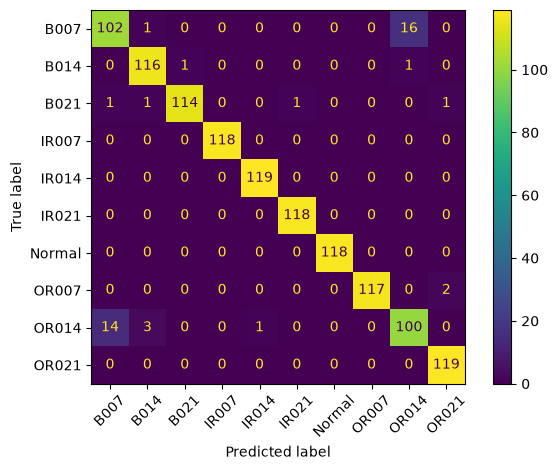

              precision    recall  f1-score   support

        B007       0.87      0.86      0.86       119
        B014       0.96      0.98      0.97       118
        B021       0.99      0.97      0.98       118
       IR007       1.00      1.00      1.00       118
       IR014       0.99      1.00      1.00       119
       IR021       0.99      1.00      1.00       118
      Normal       1.00      1.00      1.00       118
       OR007       1.00      0.98      0.99       119
       OR014       0.85      0.85      0.85       118
       OR021       0.98      1.00      0.99       119

    accuracy                           0.96      1184
   macro avg       0.96      0.96      0.96      1184
weighted avg       0.96      0.96      0.96      1184



In [38]:
from matplotlib import pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, xticks_rotation=45)
plt.tight_layout(); plt.show()

print(classification_report(y_test, clf.predict(X_test)))

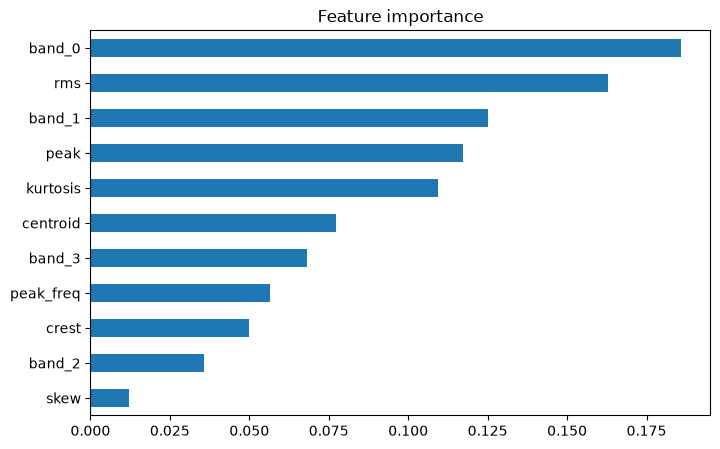

In [37]:
import matplotlib.pyplot as plt

importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values()
importances.plot(kind='barh', figsize=(8, 5))
plt.title('Feature importance')
plt.show()